In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import os

import numpy as np
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib
import matplotlib.pyplot as plt

from pycbc.frame import read_frame
from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter

# Source known parameters
m = 30

file_name = "challenge2.gwf"
URL = "https://dcc.ligo.org/public/0187/G2300818/001/" + file_name

channel_name = "H1:CHALLENGE2"

# Parameters of pre-processing steps
highpass_cutoff = 15.0
downsample_freq = 2048
strain_crop     = 2

# Parameters for PSD computation
welch_segment_length = 4

# Waveform parameters
waveform_cutoff = 20

# SNR
snr_crop = 4

In [2]:
if not os.path.isfile(file_name):
  print("Downloading data file")
  import urllib
  urllib.request.urlretrieve(URL, file_name)
  print('Getting : {}'.format(URL))
else:
  print("No downloading")

Getting : https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf


Signal: duration=128.0s, delta_t=0.000244140625s, delta_f=0.0078125Hz (sampling rate=128.0Hz)


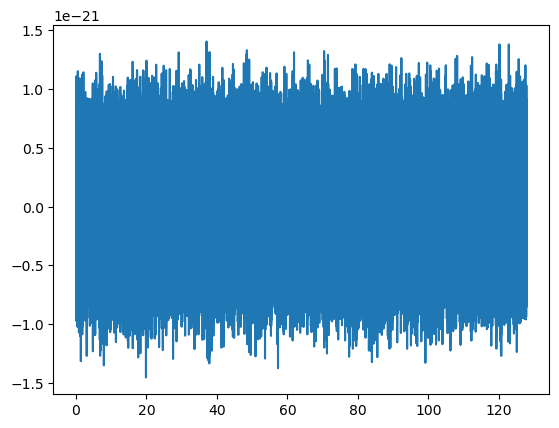

In [3]:
# Read and plot data
ts = read_frame(file_name, channel_name)
print(f"Signal: duration={ts.duration}s, delta_t={ts.delta_t}s, delta_f={ts.delta_f}Hz (sampling rate={1/ts.delta_f}Hz)")
ts.plot();

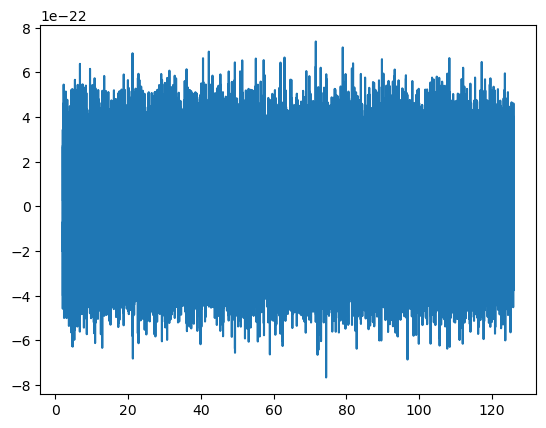

In [4]:
# Remove the low frequency content and downsample the data
strain = resample_to_delta_t(
    highpass(ts, highpass_cutoff),
    1/downsample_freq
)
conditioned = strain.crop(strain_crop, strain_crop)
conditioned.plot();

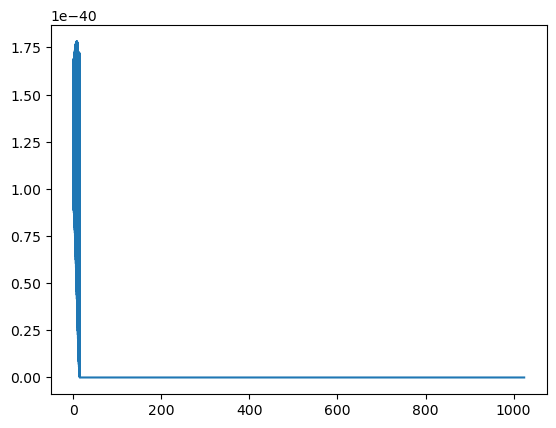

In [5]:
# Compute and plot PSD
psd = inverse_spectrum_truncation(
    interpolate(
        conditioned.psd(welch_segment_length),
        conditioned.delta_f
    ),
    int(4 * conditioned.sample_rate),
    low_frequency_cutoff=highpass_cutoff # Use the same cutoff
)
psd.plot();

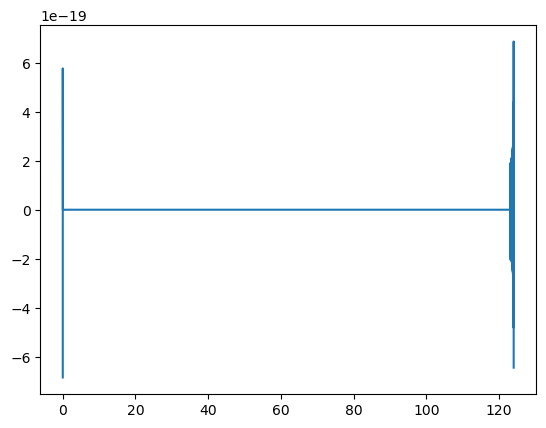

In [6]:
# Generate the template
hp, hc = get_td_waveform(
    approximant="SEOBNRv4_opt",
    mass1=m,
    mass2=m,
    delta_t=conditioned.delta_t,
    f_lower=waveform_cutoff
)

# Resize the vector to match our data
hp.resize(len(conditioned))

# Shift template
template = hp.cyclic_time_shift(hp.start_time)
template.plot();

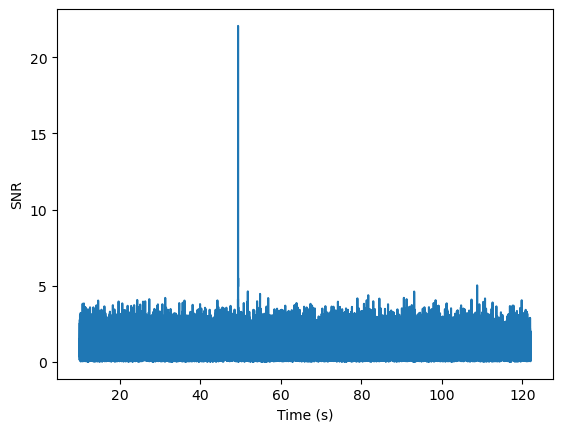

In [7]:
# Compute SNR
snr = abs(matched_filter(
    template, conditioned, psd=psd,
    low_frequency_cutoff=waveform_cutoff
))
snr = snr.crop(snr_crop + 4, snr_crop)
snr.plot()
plt.xlabel("Time (s)")
plt.ylabel("SNR");

In [8]:
# Find peak
peak  = snr.numpy().argmax()
snrp  = snr[peak]
timep = snr.sample_times[peak]
print(f"Find peak at {timep}s (SNR {snrp})")

Find peak at 49.3671875s (SNR 22.057869877957554)
